# CGAN练习(FashionMnist)

## 导入库

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time
import glob
import tensorflow as tf

from IPython import display

## 1、数据处理

In [2]:
# 导入fashion mnist数据集
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [3]:
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5   # 将图片标准化到[-1, 1]之间

train_labels = tf.one_hot(train_labels, depth=10)   # 将标签转换为one-hot编码
train_labels = tf.cast(train_labels, tf.float32)

In [4]:
buffer_size = 60000
batch_size = 256

In [5]:
# 批量化和打乱数据
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels)).shuffle(buffer_size).batch(batch_size)

## 2、生成器定义

In [6]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(110,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)  # 注意：batch size 没有限制

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())   

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model

## 3、判别器定义

In [7]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 2]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

## 4、进度监视用生成图像条件输入

In [8]:
# 定义超参数
epochs = 100
noise_dim = 100
num_examples_to_generate = 100

In [9]:
# 产生随机种子作为输入
seed = tf.random.normal([num_examples_to_generate, noise_dim])

# 有规律设置标签
labels = [i%10 for i in range(num_examples_to_generate)]    # 初始化标签向量
labels = tf.one_hot(labels, depth=10)   # 将标签转换为one-hot编码
labels = tf.cast(labels, tf.float32)    # 将标签转换为float32类型
seed = tf.concat([seed, labels], axis=1)   # 将随机种子和标签连接起来，作为生成器的输入
print(seed.shape)

(100, 110)


## 5、单次训练过程

In [ ]:
# 实例化生成器和判别器
generator = make_generator_model()
discriminator = make_discriminator_model()

# 定义损失函数（二分类交叉熵）
cross_entropy = tf.keras.losses.BinaryCrossentropy()

def generator_loss(fake_output):
    """生成器损失：希望假样本被判定为真（标签=1）"""
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    """判别器损失：希望真样本判定为真（标签=1），假样本判定为假（标签=0）"""
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

# 定义优化器
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# 定义checkpoint用于保存模型
checkpoint_dir = './CGAN_training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

# 生成图片的保存目录
generated_images_dir = './generated_images'
os.makedirs(generated_images_dir, exist_ok=True)

# 生成并保存图片的工具函数
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(10, 10))
    for i in range(predictions.shape[0]):
        plt.subplot(10, 10, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig(os.path.join(generated_images_dir, 'image_at_epoch_{:04d}.png'.format(epoch)))
    plt.show()

In [11]:
@tf.function
def train_step(data_batch):
    images = data_batch[0]
    labels = data_batch[1]
    batch_size = images.shape[0]

    # 构造标签条件输入：将 one-hot 标签(10维)扩展为与图像相同空间维度的条件张量
    labels_input = tf.concat([labels, labels, tf.zeros([batch_size, 8], dtype='float32')], 1)
    labels_input = tf.reshape(labels_input, [batch_size, 28, 1])
    labels_input = labels_input * tf.ones([batch_size, 28, 28], dtype='float32')
    labels_input = tf.reshape(labels_input, [batch_size, 28, 28, 1])

    # 生成随机噪声并拼接标签作为生成器输入
    noise = tf.random.normal([batch_size, noise_dim])
    noise_input = tf.concat([noise, labels], axis=1)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise_input, training=True)
        img_input = tf.concat([images, labels_input], axis=3)
        gen_input = tf.concat([generated_images, labels_input], axis=3)

        real_output = discriminator(img_input, training=True)
        fake_output = discriminator(gen_input, training=True)

        # 计算损失
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # 计算梯度
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # 应用梯度更新权重
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [12]:
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for i, image_batch in enumerate(dataset):
            g, d = train_step(image_batch)
            print("batch %d, gen_loss %f, disc_loss %f" % (i, g.numpy(), d.numpy()))

        # 每个epoch结束后生成图片
        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)
        
        # 保存模型
        if (epoch + 1) % 5 == 0:
            # save_dir = './CGAN_ModelSave'
            # generator.save(os.path.join(save_dir, f'gan_fashion-mnist_tf_{epoch+1}.h5'))
            checkpoint.save(file_prefix=checkpoint_prefix)
        print('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

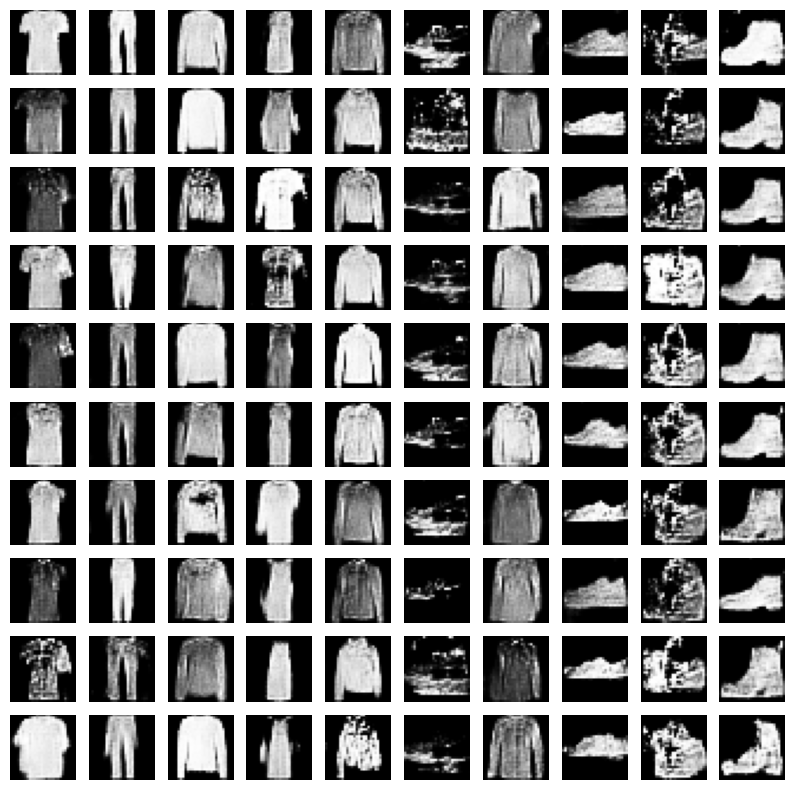

Time for epoch 100 is 11.286106586456299 sec
CPU times: total: 18min 15s
Wall time: 18min 29s


In [13]:
%%time
train(train_dataset, epochs)

## 6、使用训练好的模型生成图片

In [ ]:
# Fashion-MNIST 类别名称
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def generate_by_class(class_labels):
    """
    使用训练好的 CGAN 生成器按指定类别生成图片
    class_labels: 整数列表，每个值范围 0~9，表示要生成的 Fashion-MNIST 类别
    
    原理：CGAN 的生成器输入 = 随机噪声(100维) + 类别标签(one-hot 10维) = 110维
         通过指定不同的标签，可以控制生成器输出对应类别的图片
    """
    n = len(class_labels)
    noise = tf.random.normal([n, noise_dim])
    labels_onehot = tf.one_hot(class_labels, depth=10)
    labels_onehot = tf.cast(labels_onehot, tf.float32)
    gen_input = tf.concat([noise, labels_onehot], axis=1)
    
    generated = generator(gen_input, training=False)
    
    fig = plt.figure(figsize=(n * 2, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(generated[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.title(class_names[class_labels[i]], fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 演示1：每个类别各生成一张图片
print("=== 全部10个类别各生成一张 ===")
generate_by_class([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
# 演示2：生成同一个类别的多个样本（例如：Sneaker = 7）
print("=== 生成Sneaker(运动鞋)的多个样本 ===")
generate_by_class([7, 7, 7, 7, 7, 7, 7, 7])

print("\n提示：如果要重新加载之前训练好的模型，请运行以下代码：")
print("# checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))")